In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modelling LSTM

In [2]:
# Membaca file Excel 'Curah Hujan_2011-2020.xlsx' menggunakan engine 'openpyxl'
df = pd.read_excel(r"C:\Users\asus\OneDrive\Desktop\Lengkap Berkas Skripsi\Data\Data empiris\Curah Hujan_2011-2020_FIX.xlsx", engine='openpyxl')

In [3]:
# Mengubah kolom 'Time' menjadi format datetime dengan format 'yyyy-mm-dd'
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d')

In [4]:
df['Temp_7'] = df['Temperature/°C'].shift(7)


In [6]:
df['Hum_7'] = df['Humidity/%'].shift(7)


In [8]:
# Membuat variabel lag untuk curah hujan (Rainfall) dengan pergeseran beberapa hari yang telah ditentukan
lag_ch = [1, 3, 4, 6, 7, 9, 10, 11, 12, 15, 16, 18, 21, 22, 24, 25, 26]
for i in lag_ch:
    df[f'Ch_lag{i}'] = df['Curah Hujan/mm'].shift(i)

In [9]:
# Membuat variabel rata-rata curah hujan berdasarkan jendela waktu dari 2 hingga 30 hari
window_ch = list(range(2, 31))
for i in window_ch:
    df[f'Ch_win{i}'] = df['Curah Hujan/mm'].rolling(window=i, min_periods=1).mean()

In [10]:
# Mengisi nilai yang hilang (NaN) dengan metode backfill
df.fillna(method = 'bfill', inplace = True)
# Mengisi nilai yang hilang (NaN) dengan metode forward fill
df.fillna(method = 'ffill', inplace = True)

C:\Users\asus\AppData\Local\Temp\ipykernel_25780\2781384648.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = 'bfill', inplace = True)
C:\Users\asus\AppData\Local\Temp\ipykernel_25780\2781384648.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = 'ffill', inplace = True)


In [11]:
# Menghapus kolom 'Time' dari DataFrame
df_final = df.drop(['Time'], axis=1)

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
# Melakukan normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_final)

In [1]:
# Mendefinisikan panjang urutan dan jumlah fitur
sequence_length = 1
num_features = len(df_final.columns)

NameError: name 'df_final' is not defined

In [15]:
# Membuat urutan data dan label yang sesuai
sequences = []
labels = []
for i in range(len(scaled_data) - sequence_length):
    seq = scaled_data[i:i + sequence_length]
    label = scaled_data[i + sequence_length][5]  # Mengambil label dari kolom ke-5 yang merupakan 'Curah Hujan/mm'
    sequences.append(seq)
    labels.append(label)

In [16]:
# Mengubah daftar menjadi array numpy
sequences = np.array(sequences)
labels = np.array(labels)

In [17]:
# Membagi data menjadi data latih (2011-2019) dan data uji (2020). 
# Total 3287 data latih dan 366 data uji
train_x, train_y = sequences[:3287], labels[:3287]
test_x, test_y = sequences[3287:], labels[3287:]

In [18]:
# Mencetak bentuk (shape) dari data latih dan data uji
print("Train X shape:", train_x.shape)
print("Train Y shape:", train_y.shape)
print("Test X shape:", test_x.shape)
print("Test Y shape:", test_y.shape)

Train X shape: (3287, 1, 60)
Train Y shape: (3287,)
Test X shape: (365, 1, 60)
Test Y shape: (365,)


In [19]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import RMSprop, Adam
import random
import tensorflow as tf

In [20]:
# Membuat model LSTM
model = Sequential()
model.add(LSTM(20, input_shape=(sequence_length, num_features), return_sequences = False, activation='tanh'))
model.add(Dense(1))

c:\Users\asus\miniconda3\envs\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
# Early stopping untuk mencegah overfitting
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

In [22]:
# Mengompilasi model dengan optimizer Adam dan loss function MSE
model.compile(optimizer = Adam(learning_rate = 0.01), loss = 'mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20)             │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,501 (25.39 KB)

 Trainable params: 6,501 (25.39 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Melatih model dengan data latih, dengan validasi 10% dari data latih
history = model.fit(train_x, train_y, epochs = 100, batch_size = 64, validation_split = 0.1,
                    verbose = 1, callbacks = [early_stopping])

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3251 - val_loss: 1.2429
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2555 - val_loss: 1.2597
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2626 - val_loss: 1.2289
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2521 - val_loss: 1.2960
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2766 - val_loss: 1.4762
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2180 - val_loss: 1.1971
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2176 - val_loss: 1.2512
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2082 - val_loss: 1.2504
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1914 - val_loss: 1.2965
Epoch 10/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1835 - val_loss: 1.3976
Epoch 11/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1904 - val_loss: 1.3165
Epoch 12/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

In [24]:
# Mengevaluasi model terbaik pada data uji
test_loss = model.evaluate(test_x, test_y)
print("Test Loss:", test_loss)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.9355 
Test Loss: 3.208275318145752


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


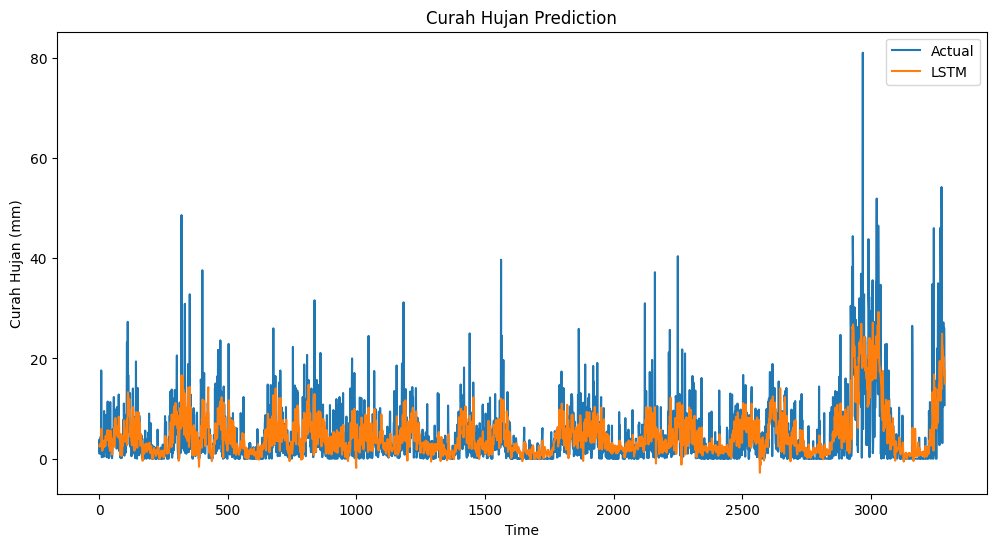

In [26]:
# Membuat plot untuk data latih dan prediksi pada data latih
train_y_copies = np.repeat(train_y.reshape(-1, 1), train_x.shape[-1], axis=-1)
true_rain_train = scaler.inverse_transform(train_y_copies)[:, 5]

prediction_train = model.predict(train_x)
prediction_copies_train = np.repeat(prediction_train, 60, axis=-1)
predicted_rain_train = scaler.inverse_transform(prediction_copies_train)[:, 5]

plt.figure(figsize=(12, 6))
plt.plot(true_rain_train, label='Actual')
plt.plot(predicted_rain_train, label='LSTM')
plt.title('Curah Hujan Prediction')
plt.xlabel('Time')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.show()

In [27]:
# Menghitung MAE, RMSE untuk data latih dan prediksi pada data latih
mae_train = mean_absolute_error(true_rain_train, predicted_rain_train)
rmse_train = np.sqrt(mean_squared_error(true_rain_train, predicted_rain_train))

print('MAE Training: {}'.format(mae_train))
print('RMSE Training: {}'.format(rmse_train))

MAE Training: 2.9599865859342103
RMSE Training: 4.67051433670824


In [28]:
# Membuat prediksi untuk data uji menggunakan model yang sudah dilatih
predictions = model.predict(test_x)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [29]:
# Mengambil nilai aktual curah hujan pada data uji
test_y_copies = np.repeat(test_y.reshape(-1, 1), test_x.shape[-1], axis=-1)
true_rain = scaler.inverse_transform(test_y_copies)[:, 5]

In [30]:
# Mengambil nilai prediksi curah hujan pada data uji
prediction = model.predict(test_x)
prediction_copies = np.repeat(prediction, 60, axis = -1)
predicted_rain = scaler.inverse_transform(prediction_copies)[:, 5]

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


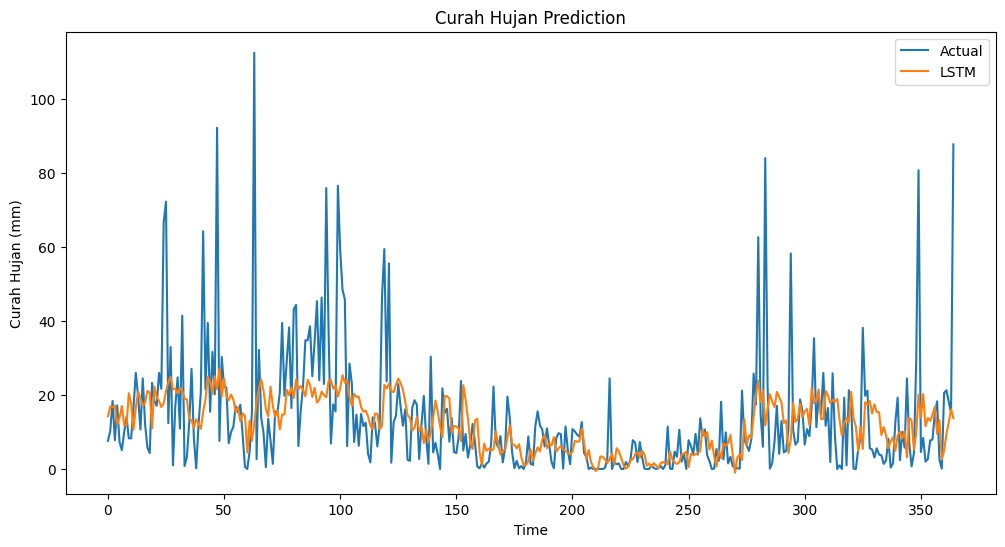

In [31]:
# Membuat plot nilai aktual dan prediksi curah hujan pada data uji
plt.figure(figsize=(12, 6))
plt.plot(true_rain, label='Actual')
plt.plot(predicted_rain, label='LSTM')
plt.title('Curah Hujan Prediction')
plt.xlabel('Time')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.show()

In [32]:
# Menghitung metrik evaluasi MAE dan rmse untuk data uji
mae = mean_absolute_error(true_rain, predicted_rain)
mse = mean_squared_error(true_rain, predicted_rain)

print('MAE Test: {}'.format(mae))
print('RMSE Test: {}'.format(np.sqrt(mse)))

MAE Test: 9.255306017215121
RMSE Test: 15.000452801983652


# Hyperparameter Tuning

In [33]:
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam, RMSprop
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

In [34]:
# Mengatur kolom 'Time' sebagai indeks DataFrame
df.set_index('Time', inplace=True)

In [35]:
# Fungsi untuk melakukan walk-forward validation dengan hyperparameter tuning
def walk_forward_validation(df, window_size = 5):
    years = df.index.year.unique()  # Mengambil tahun yang unik dari indeks DataFrame
    
    results = []  # List untuk menyimpan hasil

    sequence_length = 30  # Panjang urutan untuk LSTM
    num_features = len(df.columns)  # Jumlah fitur dalam DataFrame

    # Grid hyperparameter untuk tuning
    param_grid = {
        'optimizer': ['adam', 'rmsprop'],  # Optimizer yang akan digunakan
        'learning_rate': [0.001, 0.01, 0.1, 0.3],  # Variasi learning rate
        'epochs': [50, 100, 150, 200]  # Jumlah epoch untuk pelatihan
    }

    # Loop untuk walk-forward validation
    for i in range(len(years) - window_size):
        print(f'Window {i+1}/{len(years) - window_size}')
        train_start = years[i]  # Tahun awal data latih
        train_end = years[i + window_size - 2]  # Tahun akhir data latih 
        test_start = years[i + window_size - 1]  # Tahun awal data uji

        # Membuat mask untuk memilih data latih dan data uji berdasarkan tahun
        train_mask = (df.index.year >= train_start) & (df.index.year < train_start + 4)
        test_mask = (df.index.year == train_start + 4)

        train = df[train_mask]  # Data latih
        test = df[test_mask]  # Data uji

        # Melakukan normalisasi data latih
        scaler = StandardScaler()
        scaled_data_train = scaler.fit_transform(train)

        # Membuat urutan data dan label yang sesuai untuk data latih
        sequences_train = []
        labels_train = []
        for i in range(len(scaled_data_train) - sequence_length):
            seq = scaled_data_train[i:i + sequence_length]
            label = scaled_data_train[i + sequence_length][5]  # Label adalah curah hujan
            sequences_train.append(seq)
            labels_train.append(label)

        # Mengubah list menjadi array numpy
        sequences_train = np.array(sequences_train)
        labels_train = np.array(labels_train)

        # Memisahkan data latih menjadi fitur (X) dan label (y)
        train_x, train_y = sequences_train, labels_train

        # Membuat urutan data dan label yang sesuai untuk data uji
        sequences_test = []
        labels_test = []
        scaled_data_test = scaler.transform(test)
        for i in range(len(scaled_data_test) - sequence_length):
            seq = scaled_data_test[i:i + sequence_length]
            label = scaled_data_test[i + sequence_length][5]  # Label adalah curah hujan
            sequences_test.append(seq)
            labels_test.append(label)

        # Mengubah list menjadi array numpy
        sequences_test = np.array(sequences_test)
        labels_test = np.array(labels_test)

        # Memisahkan data uji menjadi fitur (X) dan label (y)
        test_x, test_y = sequences_test, labels_test

        # Loop untuk setiap kombinasi parameter dalam grid
        for params in tqdm(list(ParameterGrid(param_grid))):
            model = Sequential()  # Membuat model sekuensial
            model.add(LSTM(64, input_shape=(sequence_length, num_features), return_sequences=True))
            model.add(LSTM(32))
            model.add(Dense(1, activation='linear'))  # Output adalah curah hujan

            # Menggunakan early stopping untuk mencegah overfitting
            early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

            # Memilih optimizer berdasarkan parameter
            if params['optimizer'] == 'adam':
                optimizer = Adam(learning_rate=params['learning_rate'])
            else:
                optimizer = RMSprop(learning_rate=params['learning_rate'])

            model.compile(optimizer=optimizer, loss='mse')  # Mengompilasi model

            # Melatih model pada data latih
            history = model.fit(train_x, train_y, epochs=params['epochs'], batch_size=64, validation_split=0.1,
                                verbose=0, callbacks=[early_stopping])
            
            # Mengevaluasi model terbaik pada data uji
            predictions = model.predict(test_x)
            predictions = np.array(predictions).reshape(-1, 1)
            predictions = scaler.inverse_transform(np.repeat(predictions, num_features, axis=-1))[:, 5]

            # Mengambil nilai aktual curah hujan pada data uji
            test_y_copies = np.repeat(test_y.reshape(-1, 1), test_x.shape[-1], axis=-1)
            true_rain = scaler.inverse_transform(test_y_copies)[:, 5]

            # Menghitung metrik evaluasi: MAE, RMSE
            mae = mean_absolute_error(true_rain, predictions)
            rmse = np.sqrt(mean_squared_error(true_rain, predictions))

            # Menyimpan hasil untuk setiap kombinasi parameter
            results.append({
                'train_start': train_start,
                'train_end': train_end,
                'test': test_start,
                'optimizer': params['optimizer'],
                'learning_rate': params['learning_rate'],
                'epochs': params['epochs'],
                'MAE': mae,
                'RMSE': rmse,
            })

    return pd.DataFrame(results)

In [36]:
# Menjalankan walk-forward validation dengan hyperparameter tuning
results = walk_forward_validation(df, window_size = 5)

Window 1/5


  0%|          | 0/32 [00:00<?, ?it/s]c:\Users\asus\miniconda3\envs\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step


  3%|▎         | 1/32 [00:18<09:46, 18.91s/it]c:\Users\asus\miniconda3\envs\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step


...

 94%|█████████▍| 30/32 [11:22<00:40, 20.23s/it]c:\Users\asus\miniconda3\envs\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step


 97%|█████████▋| 31/32 [12:49<00:40, 40.01s/it]c:\Users\asus\miniconda3\envs\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step


100%|██████████| 32/32 [13:45<00:00, 25.79s/it]


In [37]:
# Menyimpan hasil ke file Excel
results.to_excel('results_walk_forward_lstm_1.xlsx', index = False)

In [38]:
# Menghitung rata-rata RMSE untuk setiap kombinasi hyperparameter
df_avg_rmse = results.groupby(['optimizer', 'learning_rate', 'epochs'])['RMSE'].mean().sort_values()
df_avg_rmse_1 = pd.DataFrame(df_avg_rmse)
print(df_avg_rmse_1)

                                    RMSE
optimizer learning_rate epochs          
adam      0.010         50      5.537175
          0.100         50      5.578557
          0.010         150     5.580452
rmsprop   0.010         150     5.592148
adam      0.010         100     5.635480
          0.100         150     5.637935
rmsprop   0.010         50      5.646995
adam      0.010         200     5.657018
          0.100         200     5.674284
rmsprop   0.010         100     5.690449
adam      0.100         100     5.746760
          0.300         200     5.747135
                        150     5.751651
rmsprop   0.100         200     5.759214
adam      0.300         50      5.764573
rmsprop   0.010         200     5.795578
          0.100         50      5.801147
adam      0.001         100     5.804452
          0.300         100     5.856679
          0.001         50      5.887132
rmsprop   0.100         150     5.928468
adam      0.001         150     5.944895
rmsprop   0.100 

In [39]:
# Menghitung rata-rata MAE untuk setiap kombinasi hyperparameter
df_avg_mae = results.groupby(['optimizer', 'learning_rate', 'epochs'])['MAE'].mean().sort_values()
df_avg_mae_1 = pd.DataFrame(df_avg_mae)
print(df_avg_mae_1)

                                     MAE
optimizer learning_rate epochs          
adam      0.010         150     3.515672
                        50      3.516778
          0.100         50      3.572123
rmsprop   0.010         100     3.575873
adam      0.010         200     3.607762
                        100     3.631898
rmsprop   0.010         150     3.633547
                        50      3.665873
adam      0.100         200     3.683501
rmsprop   0.010         200     3.689612
adam      0.100         150     3.689779
                        100     3.730562
          0.001         100     3.754165
          0.300         50      3.777568
                        150     3.829781
rmsprop   0.100         200     3.843053
adam      0.001         50      3.857500
          0.300         100     3.880785
rmsprop   0.001         150     3.889270
adam      0.001         200     3.891414
                        150     3.901546
rmsprop   0.001         200     3.902041
                

In [40]:
# Mengekspor hasil ke file CSV
df_avg_rmse_1.to_csv('LSTM_walk_forward_tuning_Rata2_RMSE.csv', index=True)
df_avg_mae_1.to_csv('LSTM_walk_forward_tuning_Rata2_MAE.csv', index=True)